In [1]:
# ==========================================
# الخلية 1: تثبيت المكتبات اللازمة والاستيراد
# ==========================================
!pip install -q transformers datasets accelerate scikit-learn pandas seaborn matplotlib torch

import os
import re
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

print("✅ جميع المكتبات تم تثبيتها واستيرادها بنجاح.")

✅ جميع المكتبات تم تثبيتها واستيرادها بنجاح.


In [2]:
# ==========================================
# الخلية 2: توليد التسميات باستخدام القواعد الهرمية
# ==========================================
def generate_repo_labels(df):
    HIERARCHY = ['AI', 'Data Science', 'Mobile', 'DevOps', 'Web']
    FULL_NAMES = {
        'AI': 'AI / Machine Learning', 'Data Science': 'Data Science',
        'Mobile': 'Mobile Applications', 'DevOps': 'DevOps', 'Web': 'Web Development'
    }
    KEYWORDS = {
        'AI': ['machine-learning', 'deep-learning', 'neural-network', 'tensorflow',
               'pytorch', 'llm', 'transformer', 'artificial-intelligence', 'nlp',
               'computer-vision', 'keras', 'scikit-learn'],
        'Data Science': ['data-science', 'pandas', 'numpy', 'data-analysis', 'visualization',
                         'matplotlib', 'jupyter', 'data-mining', 'big-data', 'sql'],
        'Mobile': ['android', 'ios', 'mobile', 'flutter', 'react-native', 'swift',
                   'kotlin', 'xamarin', 'mobile-app'],
        'DevOps': ['docker', 'kubernetes', 'ci-cd', 'devops', 'aws', 'azure', 'gcp',
                   'terraform', 'ansible', 'jenkins', 'cloud', 'infrastructure'],
        'Web': ['react', 'frontend', 'backend', 'web', 'javascript', 'vue', 'angular',
                'nodejs', 'express', 'django', 'flask', 'html', 'css', 'rest-api', 'graphql']
    }

    def classify_row(row):
        topics = row.get('topics_list', [])
        if isinstance(topics, str):
            try:
                import ast
                topics = ast.literal_eval(topics)
            except:
                topics = [t.strip() for t in topics.replace('|', ',').split(',') if t.strip()]

        topics_lower = [t.lower() for t in topics]
        matched = {}
        for cat, kws in KEYWORDS.items():
            count = sum(1 for kw in kws if kw.lower() in topics_lower)
            if count > 0: matched[cat] = count

        if not matched: return None, 0.0, "No matching topics found"

        for priority_cat in HIERARCHY:
            if priority_cat in matched:
                confidence = min(0.95, (matched[priority_cat] / len(KEYWORDS[priority_cat])) * 2 + 0.5)
                reason = f"Matched {matched[priority_cat]} keywords for {FULL_NAMES[priority_cat]}"
                return FULL_NAMES[priority_cat], round(confidence, 2), reason
        return None, 0.0, "Fallback: No priority match"

    results = df.apply(classify_row, axis=1)
    df['label'] = [r[0] for r in results]
    df['confidence'] = [r[1] for r in results]
    df['reason'] = [r[2] for r in results]
    return df[['name', 'description', 'readme', 'topics_list', 'label', 'confidence', 'reason']]

# 🚀 التنفيذ:
df_raw = pd.read_csv('/content/cleaned_data.csv')
df_labeled = generate_repo_labels(df_raw)
df_labeled.dropna(subset=['label'], inplace=True)
print("✅ تم توليد التسميات وحذف القيم المفقودة.")
print(df_labeled.head())

✅ تم توليد التسميات وحذف القيم المفقودة.
                name                                        description  \
0         tensorflow  An Open Source Machine Learning Framework for ...   
1       prompts.chat  f.k.a. Awesome ChatGPT Prompts. Share, discove...   
2       transformers  🤗 Transformers: the model-definition framework...   
3            pytorch  Tensors and Dynamic neural networks in Python ...   
4  LLMs-from-scratch  Implement a ChatGPT-like LLM in PyTorch from s...   

                                              readme  \
0  <div align="center">\n  <img src="https://www....   
1  <h1 align="center">\n  <a href="https://prompt...   
2  <!---\nCopyright 2020 The HuggingFace Team. Al...   
3  ![PyTorch Logo](https://github.com/pytorch/pyt...   
4  # Build a Large Language Model (From Scratch)\...   

                                         topics_list                  label  \
0  ['deep-learning', 'deep-neural-networks', 'dis...  AI / Machine Learning   
1  ['ai', 'ar

/tmp/ipykernel_1329/1735437259.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_labeled.dropna(subset=['label'], inplace=True)


In [3]:
# ==========================================
# الخلية 3: دمج الفئات وحساب أوزان التصنيف
# ==========================================
def merge_and_prepare_data(df_labeled):
    df_merged = df_labeled.copy()

    # الدمج (Data Science → AI)
    df_merged['label'] = df_merged['label'].replace({'Data Science': 'AI / Machine Learning'})

    label2id = {
        'AI / Machine Learning': 0, 'DevOps': 1,
        'Mobile Applications': 2, 'Web Development': 3
    }
    id2label = {v: k for k, v in label2id.items()}

    from sklearn.utils.class_weight import compute_class_weight
    class_weights = compute_class_weight('balanced', classes=np.unique(df_merged['label']), y=df_merged['label'])
    class_weights = dict(enumerate(class_weights))

    df_merged['label_id'] = df_merged['label'].map(label2id)

    train_df, temp_df = train_test_split(df_merged, test_size=0.30, stratify=df_merged['label'], random_state=42)
    val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)

    print("📊 توزيع الفئات بعد الدمج:")
    print(df_merged['label'].value_counts())
    print(f"\n️  أوزان الفئات: {class_weights}")
    print(f"📈 التقسيم: Train={len(train_df)} | Val={len(val_df)} | Test={len(test_df)}")
    return train_df, val_df, test_df, label2id, id2label, class_weights

#  التنفيذ:
train_df, val_df, test_df, label2id, id2label, class_weights = merge_and_prepare_data(df_labeled)

📊 توزيع الفئات بعد الدمج:
label
AI / Machine Learning    265
DevOps                   114
Mobile Applications       52
Web Development           34
Name: count, dtype: int64

️  أوزان الفئات: {0: np.float64(0.4386792452830189), 1: np.float64(1.019736842105263), 2: np.float64(2.235576923076923), 3: np.float64(3.4191176470588234)}
📈 التقسيم: Train=325 | Val=70 | Test=70


In [4]:
# ==========================================
# الخلية 4: تنظيف النصوص وتجهيز HuggingFace Dataset
# ==========================================
def prepare_datasets(train_df, val_df, test_df, tokenizer_name="distilbert-base-uncased", max_length=512):
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

    def clean_text(text):
        if not isinstance(text, str): return ""
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'!\[.*?\]\(.*?\)', '', text)
        text = re.sub(r'<[^>]+>', ' ', text)
        text = re.sub(r'```[\s\S]*?```', ' ', text)
        text = re.sub(r'[^\w\s.,!?;:\-\']', ' ', text)
        return re.sub(r'\s+', ' ', text).strip()

    def preprocess(df):
        df = df.copy()
        df['clean_text'] = df['description'].fillna('') + " [SEP] " + df['readme'].fillna('')
        df['clean_text'] = df['clean_text'].apply(clean_text)
        return df

    train_df, val_df, test_df = preprocess(train_df), preprocess(val_df), preprocess(test_df)

    def create_hf_dataset(df):
        ds = Dataset.from_pandas(df[['clean_text', 'label_id']])
        return ds.map(
            lambda ex: tokenizer(ex['clean_text'], truncation=True, padding='max_length', max_length=max_length),
            batched=True, remove_columns=['clean_text']
        ).rename_column('label_id', 'labels')

    return create_hf_dataset(train_df), create_hf_dataset(val_df), create_hf_dataset(test_df), tokenizer

#  التنفيذ:
train_ds, val_ds, test_ds, tokenizer = prepare_datasets(train_df, val_df, test_df)
print("✅ تم تجهيز الـ Datasets بنجاح.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/325 [00:00<?, ? examples/s]

Map:   0%|          | 0/70 [00:00<?, ? examples/s]

Map:   0%|          | 0/70 [00:00<?, ? examples/s]

✅ تم تجهيز الـ Datasets بنجاح.


In [5]:
# ==========================================
# الخلية 5: تحميل DistilBERT وتجهيز أوزان الخسارة
# ==========================================
def setup_standard_model(label2id, id2label, class_weights):
    model = AutoModelForSequenceClassification.from_pretrained(
        "distilbert-base-uncased",
        num_labels=len(label2id),
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )

    class_weights_tensor = torch.tensor([class_weights[i] for i in range(len(class_weights))], dtype=torch.float32)
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"✅ تم تحميل النموذج القياسي.")
    print(f"   إجمالي البارامترات: {total_params:,} | القابلة للتدريب: {trainable_params:,}")
    return model, class_weights_tensor

# 🚀 التنفيذ:
model, class_weights_tensor = setup_standard_model(label2id, id2label, class_weights)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ تم تحميل النموذج القياسي.
   إجمالي البارامترات: 66,956,548 | القابلة للتدريب: 66,956,548


In [6]:
# ==========================================
# الخلية 6: Custom Trainer وإعدادات التدريب
# ==========================================
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

def setup_training_standard(model, train_dataset, val_dataset, class_weights_tensor):
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        return {"f1_macro": f1_score(labels, predictions, average='macro', zero_division=0)}

    training_args = TrainingArguments(
        output_dir="./distilbert_standard_github",
        eval_strategy="epoch", save_strategy="epoch",
        learning_rate=2e-5, per_device_train_batch_size=8, per_device_eval_batch_size=16,
        num_train_epochs=15, weight_decay=0.05, max_grad_norm=1.0,
        load_best_model_at_end=True, metric_for_best_model="f1_macro",
        greater_is_better=True, fp16=True, logging_steps=10,
        report_to="none", warmup_steps=50, save_total_limit=2
    )

    trainer = WeightedTrainer(
        class_weights=class_weights_tensor, model=model, args=training_args,
        train_dataset=train_dataset, eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=4)]
    )
    print("✅ تم إعداد Trainer بنجاح.")
    return trainer

# 🚀 التنفيذ:
trainer = setup_training_standard(model, train_ds, val_ds, class_weights_tensor)

✅ تم إعداد Trainer بنجاح.


🚀 بدء التدريب القياسي...



Epoch,Training Loss,Validation Loss,F1 Macro
1,1.368134,1.371536,0.208333
2,1.205497,1.067196,0.655764
3,0.845911,0.583003,0.814583
4,0.454650,0.393995,0.824882
5,0.149575,0.338792,0.852578
6,0.105577,0.378369,0.877376
7,0.049594,0.475159,0.873773
8,0.021400,0.466062,0.839632
9,0.010967,0.523804,0.839632
10,0.008443,0.505532,0.839632


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



📊 TRAINING SUMMARY
Steps: 410 | Loss: 0.4354

📊 EVALUATION ON TEST SET



📋 CLASSIFICATION REPORT:
                       precision    recall  f1-score   support

AI / Machine Learning       0.86      0.93      0.89        40
               DevOps       0.73      0.65      0.69        17
  Mobile Applications       0.89      1.00      0.94         8
      Web Development       0.67      0.40      0.50         5

             accuracy                           0.83        70
            macro avg       0.79      0.74      0.76        70
         weighted avg       0.82      0.83      0.82        70


🎯 FINAL MACRO F1: 0.7551


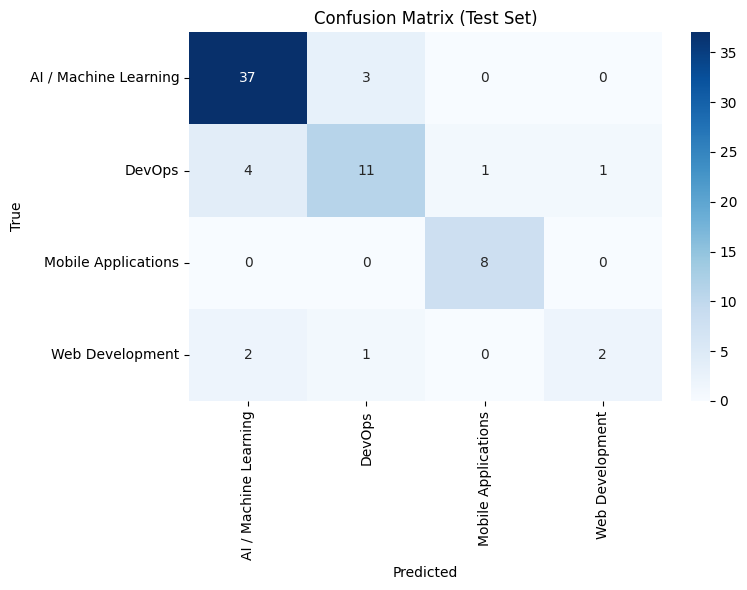

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


💾 Model saved to: ./best_distilbert_standard


In [7]:
# ==========================================
# الخلية 7: التدريب النهائي، التقييم، والحفظ
# ==========================================
def train_and_evaluate_final(trainer, test_dataset, id2label):
    print("🚀 بدء التدريب القياسي...\n")
    train_result = trainer.train()

    print("\n" + "="*50)
    print("📊 TRAINING SUMMARY")
    print("="*50)
    print(f"Steps: {train_result.global_step} | Loss: {train_result.training_loss:.4f}")

    print("\n📊 EVALUATION ON TEST SET")
    print("="*50)

    preds = trainer.predict(test_dataset)
    y_pred = np.argmax(preds.predictions, axis=-1)
    y_true = preds.label_ids

    target_names = [id2label[i] for i in range(len(id2label))]
    print("\n📋 CLASSIFICATION REPORT:")
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

    final_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"\n🎯 FINAL MACRO F1: {final_f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title('Confusion Matrix (Test Set)')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    trainer.save_model("./best_distilbert_standard")
    tokenizer.save_pretrained("./best_distilbert_standard")
    print(f"\n💾 Model saved to: ./best_distilbert_standard")
    return final_f1

# 🚀 التنفيذ النهائي:
final_f1 = train_and_evaluate_final(trainer, test_ds, id2label)